# CLIP Embedding Recommendation Ranking

## 1. Objective

The objective of this notebook is to test whether CLIP image embeddings improve the recommendation ranking quality of the Outfit Recommendation System.

The current recommendation prototype uses ResNet34 image embeddings and cosine similarity to rank catalogue items after filtering by predicted style and excluding the predicted clothing type.

In this experiment, I replace the ResNet34 embedding extractor with a CLIP image encoder.

The main research question is:

**Does replacing ResNet34 image embeddings with CLIP image embeddings improve visual coherence and overall recommendation quality in the outfit recommendation pipeline?**

The main metric I want to improve is visual coherence, which is currently 1.3750 out of 2.

I also want to check whether the overall recommendation quality improves from the current 1.40625 out of 2.

## 2. Project Context

The current recommendation system works in the following way:

1. Predict the style of the input clothing image.
2. Predict the clothing type of the input clothing image.
3. Filter the recommendation catalogue to items with the same predicted style.
4. Exclude catalogue items with the same predicted clothing type.
5. Rank the remaining candidate items using image embeddings and cosine similarity.
6. Return one recommended item per remaining clothing type.

The current selected prototype uses:

| Component | Current selected setup |
|---|---|
| Style classifier | `style_mobilenet_v3_large_architecture_comparison.pth` |
| Type classifier | `type_resnet34_extra_data.pth` |
| Catalogue | `../dataset/cleaned` |
| Embedding extractor | ResNet34 |
| Ranking method | Cosine similarity |
| Style confidence threshold | 0.60 |
| Type confidence threshold | 0.60 |

The previous experiment showed that MobileNetV3 Large improved the full recommendation pipeline compared with the previous ResNet34 style classifier.

However, visual coherence is still weaker than structural validity. This means the system usually recommends the correct clothing categories, but the selected items do not always form the best-looking outfit.

Because of this, the next improvement should focus on the recommendation ranking method.

## 3. Experiment Design

This experiment compares two recommendation ranking setups.

| Component | Baseline setup | New CLIP setup |
|---|---|---|
| Style classifier | MobileNetV3 Large | MobileNetV3 Large |
| Type classifier | Improved ResNet34 type model | Improved ResNet34 type model |
| Catalogue | `../dataset/cleaned` | `../dataset/cleaned` |
| Evaluation set | Same 32 balanced real-world examples | Same 32 balanced real-world examples |
| Embedding extractor | ResNet34 | CLIP image encoder |
| Ranking method | Cosine similarity | Cosine similarity |
| Confidence thresholds | 0.60 style, 0.60 type | 0.60 style, 0.60 type |

Only the embedding extractor changes.

This makes the comparison fair because the classifiers, catalogue, evaluation subset, confidence thresholds, and ranking method all stay the same.

The main comparison targets are:

| Metric | Current ResNet34 embedding baseline |
|---|---:|
| Visual coherence | 1.3750 / 2 |
| Overall quality | 1.40625 / 2 |
| Good recommendations | 19 |
| Partially useful recommendations | 7 |
| Bad recommendations | 6 |

## 4. Add imports

In [2]:
import os
import random
from pathlib import Path
import ast
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import models, transforms
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
# Reproducibility

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

print("Torch version:", torch.__version__)

Using device: CUDA
Torch version: 2.11.0+cu130


## 5. CLIP Dependency

This notebook uses the Hugging Face `transformers` implementation of CLIP.

The model used is:

```text
openai/clip-vit-base-patch32
```

Only the CLIP image encoder is used. The text encoder is not needed for this experiment because the recommender ranks catalogue images based on image-to-image similarity.

In [4]:
try:
    from transformers import CLIPProcessor, CLIPModel
    print("transformers is already installed.")
except ImportError:
    print("transformers is not installed. Install it with:")
    print("pip install transformers")

transformers is already installed.


## 6. Paths and Results Folder

This experiment uses the selected MobileNetV3 style classifier, the improved ResNet34 type classifier, the cleaned catalogue, and the real-world evaluation set.

The results are saved in a new folder so this experiment stays separate from the previous MobileNetV3 recommendation evaluation.

In [5]:
style_model_path = Path("../models/style_mobilenet_v3_large_architecture_comparison.pth")
type_model_path = Path("../models/type_resnet34_extra_data.pth")

catalogue_root = Path("../dataset/cleaned")
real_world_dir = Path("../dataset/real_world_test")

results_dir = Path("../results/recommendation_clip_embedding_ranking")
results_dir.mkdir(parents=True, exist_ok=True)

print("Style model exists:", style_model_path.exists())
print("Type model exists:", type_model_path.exists())
print("Catalogue exists:", catalogue_root.exists())
print("Real-world test exists:", real_world_dir.exists())
print("Results folder:", results_dir)

Style model exists: True
Type model exists: True
Catalogue exists: True
Real-world test exists: True
Results folder: ..\results\recommendation_clip_embedding_ranking


## 7. Load Selected Classifiers

This experiment keeps the selected classifiers from the current prototype.

The style classifier is the MobileNetV3 Large model because it performed best in the previous recommendation pipeline evaluation.

The type classifier is the improved ResNet34 type model because it achieved stronger real-world type accuracy.

These classifiers stay unchanged in this experiment. Only the embedding extractor used for recommendation ranking will change.

In [6]:
style_checkpoint = torch.load(
    style_model_path,
    map_location=device,
    weights_only=False
)

type_checkpoint = torch.load(
    type_model_path,
    map_location=device,
    weights_only=False
)

style_class_names = style_checkpoint["class_names"]
type_class_names = type_checkpoint["class_names"]

print("Style classes:", style_class_names)
print("Type classes:", type_class_names)

Style classes: ['formal', 'gothic', 'sporty', 'streetwear']
Type classes: ['jacket', 'pants', 'shoes', 'tshirt']


In [7]:
def load_mobilenet_v3_style_classifier(checkpoint, num_classes):
    model = models.mobilenet_v3_large(weights=None)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)

    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()

    return model


def load_resnet34_classifier(checkpoint, num_classes):
    model = models.resnet34(weights=None)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()

    return model

In [8]:
style_model = load_mobilenet_v3_style_classifier(
    style_checkpoint,
    len(style_class_names)
)

type_model = load_resnet34_classifier(
    type_checkpoint,
    len(type_class_names)
)

print("MobileNetV3 style model loaded successfully.")
print("Improved ResNet34 type model loaded successfully.")

MobileNetV3 style model loaded successfully.
Improved ResNet34 type model loaded successfully.


## 8. Classifier Image Transform

The style and type classifiers use the same ImageNet-style preprocessing as in the previous experiments.

This preprocessing is only used for the classifiers.

CLIP has its own preprocessing, which will be loaded separately from the CLIP processor.

In [9]:
classifier_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 9. Prediction and Confidence Safeguard Functions

The recommendation pipeline first predicts the style and clothing type of the input image.

The confidence thresholds stay the same as in the previous recommendation evaluation:

- style confidence threshold: 0.60
- type confidence threshold: 0.60

The confidence safeguard does not stop the recommender from producing recommendations. It only adds a status that explains whether the prediction should be treated as reliable or uncertain.

In [10]:
style_confidence_threshold = 0.60
type_confidence_threshold = 0.60

In [11]:
def predict_style_and_type(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = classifier_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        style_outputs = style_model(input_tensor)
        type_outputs = type_model(input_tensor)

        style_probs = torch.softmax(style_outputs, dim=1)
        type_probs = torch.softmax(type_outputs, dim=1)

        style_pred_idx = torch.argmax(style_probs, dim=1).item()
        type_pred_idx = torch.argmax(type_probs, dim=1).item()

        predicted_style = style_class_names[style_pred_idx]
        predicted_type = type_class_names[type_pred_idx]

        style_confidence = style_probs[0][style_pred_idx].item()
        type_confidence = type_probs[0][type_pred_idx].item()

    return {
        "style": predicted_style,
        "type": predicted_type,
        "style_confidence": style_confidence,
        "type_confidence": type_confidence
    }

In [12]:
def get_safeguard_status(style_confidence, type_confidence):
    style_uncertain = style_confidence < style_confidence_threshold
    type_uncertain = type_confidence < type_confidence_threshold

    if style_uncertain and type_uncertain:
        return "style_and_type_uncertain"

    if style_uncertain:
        return "style_uncertain"

    if type_uncertain:
        return "type_uncertain"

    return "reliable"

In [13]:
test_image_path = real_world_dir / "streetwear" / "jacket" / "streetwear_jacket_rw_001.png"

prediction = predict_style_and_type(test_image_path)

prediction["safeguard_status"] = get_safeguard_status(
    prediction["style_confidence"],
    prediction["type_confidence"]
)

prediction

{'style': 'streetwear',
 'type': 'jacket',
 'style_confidence': 0.5649640560150146,
 'type_confidence': 0.6415799856185913,
 'safeguard_status': 'style_uncertain'}

## 10. Load CLIP Model and Processor

This experiment uses CLIP only as an image embedding extractor.

The model is:

```text
openai/clip-vit-base-patch32
```

For every image, CLIP produces an image feature vector. These vectors are normalized and compared using cosine similarity.

This replaces the previous ResNet34 embedding extractor.

In [14]:
from transformers import CLIPProcessor, CLIPModel

clip_model_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)

clip_model = clip_model.to(device)
clip_model.eval()

print("CLIP model loaded:", clip_model_name)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP model loaded: openai/clip-vit-base-patch32


In [15]:
def get_clip_image_embedding(image_path):
    image = Image.open(image_path).convert("RGB")

    inputs = clip_processor(
        images=image,
        return_tensors="pt"
    )

    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        image_features = clip_model.get_image_features(
            pixel_values=pixel_values
        )

        # Some transformers versions may return an output object instead of a tensor.
        # This fallback extracts the pooled image representation if needed.
        if not torch.is_tensor(image_features):
            if hasattr(image_features, "pooler_output"):
                image_features = image_features.pooler_output
            elif hasattr(image_features, "last_hidden_state"):
                image_features = image_features.last_hidden_state[:, 0, :]
            else:
                raise TypeError(f"Unexpected CLIP output type: {type(image_features)}")

        image_features = F.normalize(image_features, p=2, dim=1)

    return image_features.cpu().numpy()[0]

In [16]:
test_embedding = get_clip_image_embedding(test_image_path)

print("Embedding shape:", test_embedding.shape)
print("First 5 values:", test_embedding[:5])

Embedding shape: (512,)
First 5 values: [-0.02859812  0.04178564  0.00337532  0.0031903  -0.02224844]


## 11. Build Catalogue with CLIP Embeddings

The recommendation catalogue is built from the cleaned dataset.

Each catalogue item stores:

- image path
- known style
- known clothing type
- filename
- embedding index

The catalogue itself does not change in this experiment. The only change is that catalogue embeddings are generated using CLIP instead of ResNet34.

In [17]:
catalogue_items = []

for style in sorted(os.listdir(catalogue_root)):
    style_path = catalogue_root / style

    if not style_path.is_dir():
        continue

    for item_type in sorted(os.listdir(style_path)):
        type_path = style_path / item_type

        if not type_path.is_dir():
            continue

        for filename in sorted(os.listdir(type_path)):
            image_path = type_path / filename

            if image_path.is_file() and filename.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                catalogue_items.append({
                    "image_path": str(image_path),
                    "style": style,
                    "type": item_type,
                    "filename": filename
                })

catalogue_df = pd.DataFrame(catalogue_items)

print("Catalogue size:", len(catalogue_df))
catalogue_df.head()

Catalogue size: 800


,image_path,style,type,filename
0,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_001.png
1,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_002.png
2,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_003.png
3,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_004.png
4,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_005.png


In [18]:
catalogue_distribution = pd.crosstab(
    catalogue_df["style"],
    catalogue_df["type"]
)

catalogue_distribution

type,jacket,pants,shoes,tshirt
style,,,,
formal,50,50,50,50
gothic,50,50,50,50
sporty,50,50,50,50
streetwear,50,50,50,50


## 12. Generate or Load CLIP Catalogue Embeddings

Generating CLIP embeddings for all catalogue images can take some time.

To avoid repeating this work every time the notebook runs, the embeddings are saved as a NumPy file.

If the file already exists, the notebook loads the saved embeddings.

In [19]:
clip_embeddings_path = results_dir / "catalogue_clip_embeddings.npy"
catalogue_csv_path = results_dir / "catalogue_clip_items.csv"

print("Embeddings path:", clip_embeddings_path)
print("Catalogue CSV path:", catalogue_csv_path)

Embeddings path: ..\results\recommendation_clip_embedding_ranking\catalogue_clip_embeddings.npy
Catalogue CSV path: ..\results\recommendation_clip_embedding_ranking\catalogue_clip_items.csv


In [20]:
if clip_embeddings_path.exists() and catalogue_csv_path.exists():
    print("Loading cached CLIP catalogue embeddings...")

    catalogue_df = pd.read_csv(catalogue_csv_path)
    catalogue_embeddings = np.load(clip_embeddings_path)

else:
    print("Generating CLIP catalogue embeddings...")

    catalogue_embeddings_list = []

    for idx, image_path in enumerate(catalogue_df["image_path"]):
        embedding = get_clip_image_embedding(image_path)
        catalogue_embeddings_list.append(embedding)

        if (idx + 1) % 50 == 0:
            print(f"Processed {idx + 1}/{len(catalogue_df)} images")

    catalogue_embeddings = np.vstack(catalogue_embeddings_list)

    catalogue_df = catalogue_df.reset_index(drop=True)
    catalogue_df["embedding_index"] = catalogue_df.index

    np.save(clip_embeddings_path, catalogue_embeddings)
    catalogue_df.to_csv(catalogue_csv_path, index=False)

print("Catalogue embeddings shape:", catalogue_embeddings.shape)
print("Catalogue rows:", len(catalogue_df))

Loading cached CLIP catalogue embeddings...
Catalogue embeddings shape: (800, 512)
Catalogue rows: 800


In [21]:
catalogue_df.head()

,image_path,style,type,filename,embedding_index
0,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_001.png,0
1,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_002.png,1
2,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_003.png,2
3,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_004.png,3
4,..\dataset\cleaned\formal\jacket\formal_jacket...,formal,jacket,formal_jacket_005.png,4


## 13. Recommendation Function with CLIP Embeddings

This function uses the same recommendation logic as before.

The steps are:

1. Predict style and clothing type.
2. Add the confidence safeguard status.
3. Generate a CLIP embedding for the input image.
4. Filter the catalogue to the predicted style.
5. Exclude the predicted clothing type.
6. Compare the input CLIP embedding with candidate CLIP embeddings.
7. Select the most similar item from each remaining clothing type.

The important difference is that similarity is now calculated using CLIP embeddings instead of ResNet34 embeddings.

In [22]:
def recommend_items_by_clip_embedding(image_path, catalogue_df, catalogue_embeddings):
    prediction = predict_style_and_type(image_path)

    predicted_style = prediction["style"]
    predicted_type = prediction["type"]

    safeguard_status = get_safeguard_status(
        prediction["style_confidence"],
        prediction["type_confidence"]
    )

    prediction["safeguard_status"] = safeguard_status

    input_embedding = get_clip_image_embedding(image_path)

    candidates = catalogue_df[
        (catalogue_df["style"] == predicted_style) &
        (catalogue_df["type"] != predicted_type)
    ].copy()

    if len(candidates) == 0:
        return prediction, candidates

    candidate_indices = candidates["embedding_index"].values
    candidate_embeddings = catalogue_embeddings[candidate_indices]

    similarities = cosine_similarity(
        candidate_embeddings,
        input_embedding.reshape(1, -1)
    ).flatten()

    candidates["similarity"] = similarities

    recommended_rows = []

    for item_type in sorted(candidates["type"].unique()):
        type_candidates = candidates[candidates["type"] == item_type]
        top_item = type_candidates.sort_values("similarity", ascending=False).head(1)
        recommended_rows.append(top_item)

    recommendations = pd.concat(recommended_rows).sort_values(
        "similarity",
        ascending=False
    )

    return prediction, recommendations

In [23]:
prediction, recommendations = recommend_items_by_clip_embedding(
    test_image_path,
    catalogue_df,
    catalogue_embeddings
)

print("Prediction:")
print(prediction)

recommendations[["style", "type", "filename", "similarity"]]

Prediction:
{'style': 'streetwear', 'type': 'jacket', 'style_confidence': 0.5649640560150146, 'type_confidence': 0.6415799856185913, 'safeguard_status': 'style_uncertain'}


,style,type,filename,similarity
764,streetwear,tshirt,streetwear_tshirt_015.png,0.688651
680,streetwear,pants,streetwear_pants_031.png,0.616822
700,streetwear,shoes,streetwear_shoes_001.png,0.596248


In [24]:
def show_recommendations(image_path, prediction, recommendations):
    num_recs = len(recommendations)

    fig, axes = plt.subplots(1, num_recs + 1, figsize=(5 * (num_recs + 1), 5))

    if num_recs == 0:
        axes = [axes]

    input_image = Image.open(image_path).convert("RGB")

    axes[0].imshow(input_image)
    axes[0].set_title(
        f"Input\n"
        f"Style: {prediction['style']} ({prediction['style_confidence']:.2f})\n"
        f"Type: {prediction['type']} ({prediction['type_confidence']:.2f})\n"
        f"Status: {prediction['safeguard_status']}"
    )
    axes[0].axis("off")

    for i, (_, row) in enumerate(recommendations.iterrows()):
        rec_image = Image.open(row["image_path"]).convert("RGB")
        axes[i + 1].imshow(rec_image)
        axes[i + 1].set_title(
            f"{row['style']} {row['type']}\n"
            f"Sim: {row['similarity']:.2f}"
        )
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()

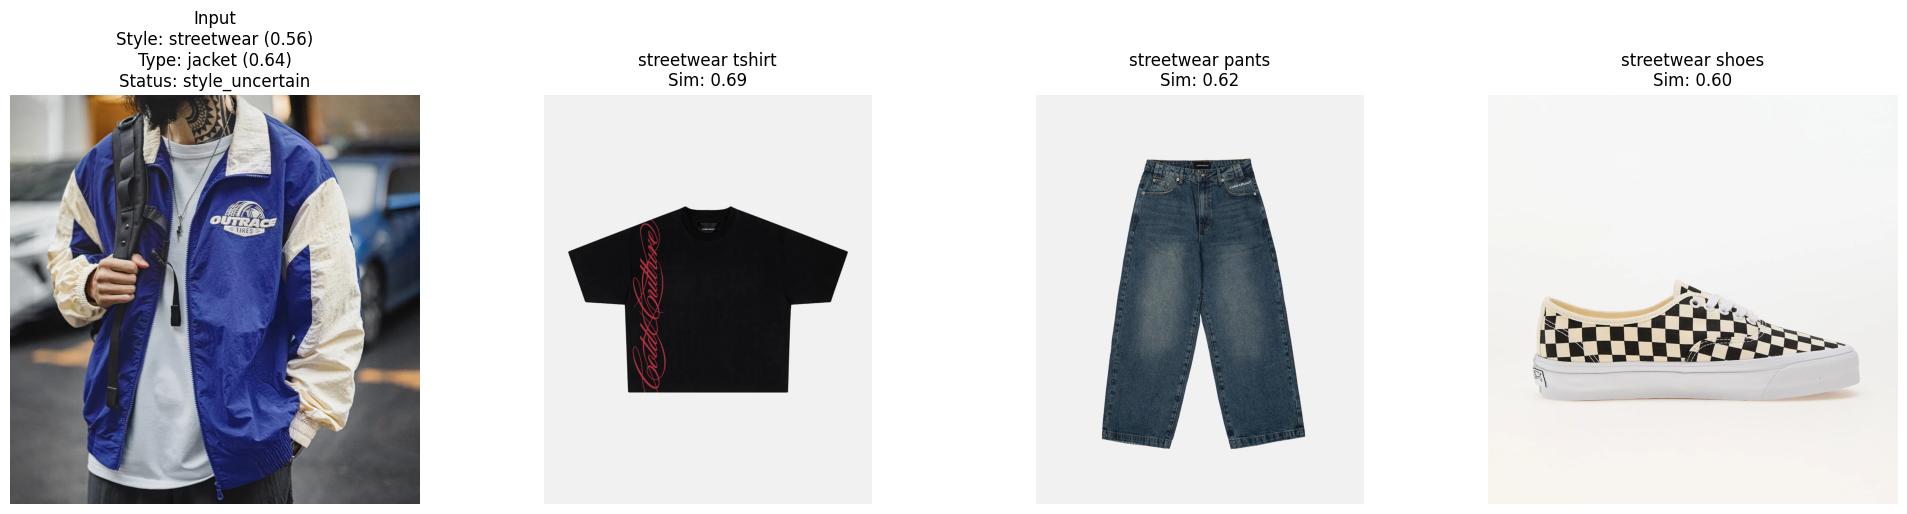

In [25]:
show_recommendations(
    test_image_path,
    prediction,
    recommendations
)

## 14. Create the 32-Example Evaluation Set

The evaluation set must stay the same as the previous recommendation experiments.

It contains:

- 4 styles
- 4 clothing types
- 2 examples per style/type combination
- 32 examples in total

The real-world test set is used only for evaluation. It is not used for training or model improvement.

In [26]:
def create_balanced_evaluation_set(real_world_dir, examples_per_combination=2):
    evaluation_items = []

    for style in sorted(os.listdir(real_world_dir)):
        style_path = real_world_dir / style

        if not style_path.is_dir():
            continue

        for item_type in sorted(os.listdir(style_path)):
            type_path = style_path / item_type

            if not type_path.is_dir():
                continue

            image_files = [
                filename for filename in sorted(os.listdir(type_path))
                if filename.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
            ]

            selected_files = image_files[:examples_per_combination]

            for filename in selected_files:
                image_path = type_path / filename

                evaluation_items.append({
                    "image_path": str(image_path),
                    "true_style": style,
                    "true_type": item_type,
                    "filename": filename
                })

    return pd.DataFrame(evaluation_items)

In [27]:
evaluation_set_path = results_dir / "clip_32_example_evaluation_set.csv"

if evaluation_set_path.exists():
    evaluation_df = pd.read_csv(evaluation_set_path)
    print("Loaded existing evaluation set.")
else:
    evaluation_df = create_balanced_evaluation_set(
        real_world_dir=real_world_dir,
        examples_per_combination=2
    )

    evaluation_df.to_csv(evaluation_set_path, index=False)
    print("Created and saved new evaluation set.")

print("Number of evaluation examples:", len(evaluation_df))
evaluation_df.head()

Loaded existing evaluation set.
Number of evaluation examples: 32


,image_path,true_style,true_type,filename
0,..\dataset\real_world_test\formal\jacket\forma...,formal,jacket,formal_jacket_rw_001.png
1,..\dataset\real_world_test\formal\jacket\forma...,formal,jacket,formal_jacket_rw_002.png
2,..\dataset\real_world_test\formal\pants\formal...,formal,pants,formal_pants_rw_001.png
3,..\dataset\real_world_test\formal\pants\formal...,formal,pants,formal_pants_rw_002.png
4,..\dataset\real_world_test\formal\shoes\formal...,formal,shoes,formal_shoes_rw_001.png


In [28]:
evaluation_distribution = pd.crosstab(
    evaluation_df["true_style"],
    evaluation_df["true_type"]
)

evaluation_distribution

true_type,jacket,pants,shoes,tshirt
true_style,,,,
formal,2,2,2,2
gothic,2,2,2,2
sporty,2,2,2,2
streetwear,2,2,2,2


## 15. Run Automatic CLIP Recommendation Evaluation

This section runs the CLIP-based recommendation pipeline on the 32 selected real-world examples.

For each example, I record:

- true style
- true clothing type
- predicted style
- predicted clothing type
- confidence scores
- safeguard status
- recommended item styles
- recommended item types
- recommended filenames
- recommendation similarity scores
- number of recommendations
- whether the output includes the same actual type as the input

In [29]:
automatic_results = []

for _, row in evaluation_df.iterrows():
    image_path = row["image_path"]
    true_style = row["true_style"]
    true_type = row["true_type"]

    prediction, recommendations = recommend_items_by_clip_embedding(
        image_path,
        catalogue_df,
        catalogue_embeddings
    )

    recommended_types = recommendations["type"].tolist() if len(recommendations) > 0 else []
    recommended_styles = recommendations["style"].tolist() if len(recommendations) > 0 else []
    recommended_files = recommendations["filename"].tolist() if len(recommendations) > 0 else []
    recommended_similarities = recommendations["similarity"].tolist() if len(recommendations) > 0 else []

    same_actual_type_issue = true_type in recommended_types

    automatic_results.append({
        "input_image": image_path,
        "filename": row["filename"],
        "true_style": true_style,
        "true_type": true_type,
        "predicted_style": prediction["style"],
        "predicted_type": prediction["type"],
        "style_confidence": prediction["style_confidence"],
        "type_confidence": prediction["type_confidence"],
        "safeguard_status": prediction["safeguard_status"],
        "style_correct": prediction["style"] == true_style,
        "type_correct": prediction["type"] == true_type,
        "recommended_styles": recommended_styles,
        "recommended_types": recommended_types,
        "recommended_files": recommended_files,
        "recommended_similarities": recommended_similarities,
        "num_recommendations": len(recommendations),
        "same_actual_type_issue": same_actual_type_issue
    })

automatic_results_df = pd.DataFrame(automatic_results)

automatic_results_df.head()

,input_image,filename,true_style,true_type,predicted_style,predicted_type,style_confidence,type_confidence,safeguard_status,style_correct,type_correct,recommended_styles,recommended_types,recommended_files,recommended_similarities,num_recommendations,same_actual_type_issue
0,..\dataset\real_world_test\formal\jacket\forma...,formal_jacket_rw_001.png,formal,jacket,formal,jacket,0.743481,0.907646,reliable,True,True,"[formal, formal, formal]","[pants, tshirt, shoes]","[formal_pants_002.png, formal_tshirt_049.png, ...","[0.772238552570343, 0.77081698179245, 0.758045...",3,False
1,..\dataset\real_world_test\formal\jacket\forma...,formal_jacket_rw_002.png,formal,jacket,formal,jacket,0.908396,0.935415,reliable,True,True,"[formal, formal, formal]","[tshirt, pants, shoes]","[formal_tshirt_009.png, formal_pants_036.png, ...","[0.5641196966171265, 0.5549345016479492, 0.547...",3,False
2,..\dataset\real_world_test\formal\pants\formal...,formal_pants_rw_001.png,formal,pants,formal,pants,0.808794,0.737623,reliable,True,True,"[formal, formal, formal]","[jacket, tshirt, shoes]","[formal_jacket_039.png, formal_tshirt_001.png,...","[0.854070782661438, 0.7868897914886475, 0.7796...",3,False
3,..\dataset\real_world_test\formal\pants\formal...,formal_pants_rw_002.png,formal,pants,sporty,pants,0.562956,0.573864,style_and_type_uncertain,False,True,"[sporty, sporty, sporty]","[jacket, tshirt, shoes]","[sporty_jacket_023.png, sporty_tshirt_049.png,...","[0.7370046377182007, 0.7207883596420288, 0.632...",3,False
4,..\dataset\real_world_test\formal\shoes\formal...,formal_shoes_rw_001.png,formal,shoes,formal,shoes,0.555320,0.978442,style_uncertain,True,True,"[formal, formal, formal]","[jacket, pants, tshirt]","[formal_jacket_039.png, formal_pants_019.png, ...","[0.7647998332977295, 0.7517022490501404, 0.729...",3,False


In [30]:
automatic_summary = {
    "num_examples": len(automatic_results_df),
    "style_accuracy": automatic_results_df["style_correct"].mean(),
    "type_accuracy": automatic_results_df["type_correct"].mean(),
    "same_actual_type_issues": int(automatic_results_df["same_actual_type_issue"].sum()),
    "same_actual_type_issue_rate": automatic_results_df["same_actual_type_issue"].mean(),
    "average_num_recommendations": automatic_results_df["num_recommendations"].mean()
}

automatic_summary_df = pd.DataFrame([automatic_summary])
automatic_summary_df

,num_examples,style_accuracy,type_accuracy,same_actual_type_issues,same_actual_type_issue_rate,average_num_recommendations
0,32,0.65625,0.9375,2,0.0625,3.0


In [31]:
safeguard_distribution = automatic_results_df["safeguard_status"].value_counts().reset_index()
safeguard_distribution.columns = ["safeguard_status", "count"]

safeguard_distribution

,safeguard_status,count
0,reliable,16
1,style_uncertain,10
2,style_and_type_uncertain,5
3,type_uncertain,1


In [32]:
style_prediction_distribution = pd.crosstab(
    automatic_results_df["true_style"],
    automatic_results_df["predicted_style"]
)

style_prediction_distribution

predicted_style,formal,gothic,sporty,streetwear
true_style,,,,
formal,5,0,2,1
gothic,0,5,0,3
sporty,2,0,4,2
streetwear,0,0,1,7


In [33]:
type_prediction_distribution = pd.crosstab(
    automatic_results_df["true_type"],
    automatic_results_df["predicted_type"]
)

type_prediction_distribution

predicted_type,jacket,pants,shoes,tshirt
true_type,,,,
jacket,8,0,0,0
pants,1,7,0,0
shoes,0,0,8,0
tshirt,1,0,0,7


## 16. Save Automatic CLIP Results

The automatic results are saved before manual evaluation.

This makes it possible to inspect the outputs, generate visual scoring sheets, and compare the CLIP ranking setup with the previous ResNet34 embedding baseline.

In [34]:
automatic_results_df.to_csv(
    results_dir / "clip_recommendation_automatic_results.csv",
    index=False
)

automatic_summary_df.to_csv(
    results_dir / "clip_recommendation_automatic_summary.csv",
    index=False
)

safeguard_distribution.to_csv(
    results_dir / "clip_safeguard_distribution.csv",
    index=False
)

style_prediction_distribution.to_csv(
    results_dir / "clip_style_prediction_distribution.csv"
)

type_prediction_distribution.to_csv(
    results_dir / "clip_type_prediction_distribution.csv"
)

print("Automatic CLIP evaluation results saved.")
print("Results folder:", results_dir)

Automatic CLIP evaluation results saved.
Results folder: ..\results\recommendation_clip_embedding_ranking


## 17. Automatic Comparison with ResNet34 Embedding Baseline

The automatic results are compared with the previous ResNet34 embedding baseline.

Since this experiment only changes the embedding extractor, the style and type prediction metrics are expected to stay the same.

The important difference should appear later in the manual recommendation quality scores, especially visual coherence and overall quality.

In [35]:
previous_automatic_summary = {
    "setup": "ResNet34 embedding baseline",
    "style_accuracy": 0.65625,
    "type_accuracy": 0.9375,
    "same_actual_type_issues": 2,
    "same_actual_type_issue_rate": 2 / 32,
    "average_num_recommendations": 3.0
}

clip_automatic_summary = {
    "setup": "CLIP embedding setup",
    "style_accuracy": automatic_summary_df.loc[0, "style_accuracy"],
    "type_accuracy": automatic_summary_df.loc[0, "type_accuracy"],
    "same_actual_type_issues": automatic_summary_df.loc[0, "same_actual_type_issues"],
    "same_actual_type_issue_rate": automatic_summary_df.loc[0, "same_actual_type_issue_rate"],
    "average_num_recommendations": automatic_summary_df.loc[0, "average_num_recommendations"]
}

automatic_comparison_df = pd.DataFrame([
    previous_automatic_summary,
    clip_automatic_summary
])

automatic_comparison_df

,setup,style_accuracy,type_accuracy,same_actual_type_issues,same_actual_type_issue_rate,average_num_recommendations
0,ResNet34 embedding baseline,0.65625,0.9375,2,0.0625,3.0
1,CLIP embedding setup,0.65625,0.9375,2,0.0625,3.0


In [36]:
automatic_comparison_df.to_csv(
    results_dir / "automatic_comparison_with_resnet34_embedding_baseline.csv",
    index=False
)

print("Automatic comparison saved.")

Automatic comparison saved.


### 17.1 Automatic Comparison Interpretation

The automatic comparison shows that the CLIP embedding setup has the same style accuracy, type accuracy, same-actual-type issue count, and average number of recommendations as the ResNet34 embedding baseline.

This is expected because the classifiers, catalogue, confidence thresholds, and evaluation subset did not change.

The automatic metrics mainly check the classification and structural parts of the pipeline. They do not show whether CLIP selected visually better recommendation items.

Because of this, the next step is manual evaluation. The main question is whether CLIP improves visual coherence and overall recommendation quality compared with the ResNet34 embedding baseline.

## 18. Create Manual Evaluation Template

The automatic results are used as the base for the manual evaluation file.

The manual evaluation uses the same scoring criteria as the previous recommendation evaluation:

| Criterion | Score range |
|---|---|
| structural validity | 0, 1, or 2 |
| style consistency | 0, 1, or 2 |
| visual coherence | 0, 1, or 2 |
| confidence warning usefulness | 0, 1, or 2 |
| overall quality | 0, 1, or 2 |

The score meaning is:

```text
0 = bad / not useful
1 = partially useful
2 = good / useful
```

The main metric for this experiment is visual coherence.

In [37]:
manual_eval_dir = results_dir / "manual_evaluation"
manual_eval_dir.mkdir(parents=True, exist_ok=True)

manual_eval_csv_path = manual_eval_dir / "clip_manual_evaluation_template.csv"

manual_eval_df = automatic_results_df.copy()

manual_score_columns = [
    "structural_validity",
    "style_consistency",
    "visual_coherence",
    "confidence_warning_usefulness",
    "overall_quality",
    "manual_notes"
]

for col in manual_score_columns:
    if col not in manual_eval_df.columns:
        manual_eval_df[col] = ""

manual_eval_df.to_csv(manual_eval_csv_path, index=False)

print("Manual evaluation template saved to:")
print(manual_eval_csv_path)

manual_eval_df.head()

Manual evaluation template saved to:
..\results\recommendation_clip_embedding_ranking\manual_evaluation\clip_manual_evaluation_template.csv


,input_image,filename,true_style,true_type,predicted_style,predicted_type,style_confidence,type_confidence,safeguard_status,style_correct,...,recommended_files,recommended_similarities,num_recommendations,same_actual_type_issue,structural_validity,style_consistency,visual_coherence,confidence_warning_usefulness,overall_quality,manual_notes
0,..\dataset\real_world_test\formal\jacket\forma...,formal_jacket_rw_001.png,formal,jacket,formal,jacket,0.743481,0.907646,reliable,True,...,"[formal_pants_002.png, formal_tshirt_049.png, ...","[0.772238552570343, 0.77081698179245, 0.758045...",3,False,,,,,,
1,..\dataset\real_world_test\formal\jacket\forma...,formal_jacket_rw_002.png,formal,jacket,formal,jacket,0.908396,0.935415,reliable,True,...,"[formal_tshirt_009.png, formal_pants_036.png, ...","[0.5641196966171265, 0.5549345016479492, 0.547...",3,False,,,,,,
2,..\dataset\real_world_test\formal\pants\formal...,formal_pants_rw_001.png,formal,pants,formal,pants,0.808794,0.737623,reliable,True,...,"[formal_jacket_039.png, formal_tshirt_001.png,...","[0.854070782661438, 0.7868897914886475, 0.7796...",3,False,,,,,,
3,..\dataset\real_world_test\formal\pants\formal...,formal_pants_rw_002.png,formal,pants,sporty,pants,0.562956,0.573864,style_and_type_uncertain,False,...,"[sporty_jacket_023.png, sporty_tshirt_049.png,...","[0.7370046377182007, 0.7207883596420288, 0.632...",3,False,,,,,,
4,..\dataset\real_world_test\formal\shoes\formal...,formal_shoes_rw_001.png,formal,shoes,formal,shoes,0.555320,0.978442,style_uncertain,True,...,"[formal_jacket_039.png, formal_pants_019.png, ...","[0.7647998332977295, 0.7517022490501404, 0.729...",3,False,,,,,,


## 19. Generate Visual Scoring Sheets

The visual scoring sheets make manual evaluation easier.

Each sheet shows four examples. Each example includes:

- the input image
- the true style and type
- the predicted style and type
- confidence values
- safeguard status
- the three recommended CLIP-ranked items

Since there are 32 examples and each sheet contains 4 examples, this creates 8 visual sheets.

In [38]:
visual_sheets_dir = manual_eval_dir / "visual_scoring_sheets"
visual_sheets_dir.mkdir(parents=True, exist_ok=True)

print("Visual sheets folder:")
print(visual_sheets_dir)

Visual sheets folder:
..\results\recommendation_clip_embedding_ranking\manual_evaluation\visual_scoring_sheets


In [39]:
def parse_saved_list(value):
    """
    Converts list-like strings or comma-separated strings into Python lists.
    """

    if isinstance(value, list):
        return value

    if isinstance(value, str):
        value = value.strip()

        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass

        if "," in value:
            return [
                item.strip().strip("'").strip('"')
                for item in value.split(",")
            ]

        if value:
            return [value.strip("'").strip('"')]

    return []

In [40]:
def build_recommendation_paths(row):
    """
    Builds full image paths for the recommended catalogue items.
    """

    styles = parse_saved_list(row.get("recommended_styles", ""))
    types = parse_saved_list(row.get("recommended_types", ""))
    files = parse_saved_list(row.get("recommended_files", ""))

    recommendation_paths = []

    for style, item_type, filename in zip(styles, types, files):
        path = catalogue_root / style / item_type / filename
        recommendation_paths.append(str(path))

    return recommendation_paths


manual_eval_df["recommendation_paths"] = manual_eval_df.apply(
    build_recommendation_paths,
    axis=1
)

manual_eval_df[
    [
        "filename",
        "recommended_styles",
        "recommended_types",
        "recommended_files",
        "recommendation_paths"
    ]
].head()

,filename,recommended_styles,recommended_types,recommended_files,recommendation_paths
0,formal_jacket_rw_001.png,"[formal, formal, formal]","[pants, tshirt, shoes]","[formal_pants_002.png, formal_tshirt_049.png, ...",[..\dataset\cleaned\formal\pants\formal_pants_...
1,formal_jacket_rw_002.png,"[formal, formal, formal]","[tshirt, pants, shoes]","[formal_tshirt_009.png, formal_pants_036.png, ...",[..\dataset\cleaned\formal\tshirt\formal_tshir...
2,formal_pants_rw_001.png,"[formal, formal, formal]","[jacket, tshirt, shoes]","[formal_jacket_039.png, formal_tshirt_001.png,...",[..\dataset\cleaned\formal\jacket\formal_jacke...
3,formal_pants_rw_002.png,"[sporty, sporty, sporty]","[jacket, tshirt, shoes]","[sporty_jacket_023.png, sporty_tshirt_049.png,...",[..\dataset\cleaned\sporty\jacket\sporty_jacke...
4,formal_shoes_rw_001.png,"[formal, formal, formal]","[jacket, pants, tshirt]","[formal_jacket_039.png, formal_pants_019.png, ...",[..\dataset\cleaned\formal\jacket\formal_jacke...


In [41]:
def create_visual_scoring_sheet(df, start_idx, end_idx, save_path):
    """
    Creates one visual scoring sheet.

    Each row shows:
    - input image
    - recommendation 1
    - recommendation 2
    - recommendation 3
    """

    selected_df = df.iloc[start_idx:end_idx].reset_index(drop=False)

    examples_count = len(selected_df)
    max_images_per_example = 4

    fig, axes = plt.subplots(
        examples_count,
        max_images_per_example,
        figsize=(max_images_per_example * 4.5, examples_count * 4.5)
    )

    if examples_count == 1:
        axes = [axes]

    for row_pos, (_, row) in enumerate(selected_df.iterrows()):
        original_index = row["index"]
        excel_row = original_index + 2

        input_path = row["input_image"]
        recommendation_paths = row["recommendation_paths"]

        if isinstance(recommendation_paths, str):
            recommendation_paths = parse_saved_list(recommendation_paths)

        all_paths = [input_path] + recommendation_paths[:3]

        for col_pos in range(max_images_per_example):
            ax = axes[row_pos][col_pos]

            if col_pos < len(all_paths):
                image_path = all_paths[col_pos]

                try:
                    img = Image.open(image_path).convert("RGB")
                    ax.imshow(img)
                except Exception:
                    ax.text(
                        0.5,
                        0.5,
                        f"Image not found:\n{image_path}",
                        ha="center",
                        va="center",
                        wrap=True
                    )

                if col_pos == 0:
                    title = (
                        f"Excel row: {excel_row}\n"
                        f"Input: {row.get('filename', '')}\n"
                        f"True: {row.get('true_style', '')} / {row.get('true_type', '')}\n"
                        f"Pred: {row.get('predicted_style', '')} / {row.get('predicted_type', '')}\n"
                        f"Style conf: {row.get('style_confidence', 0):.2f}\n"
                        f"Type conf: {row.get('type_confidence', 0):.2f}\n"
                        f"Status: {row.get('safeguard_status', '')}"
                    )
                else:
                    rec_index = col_pos - 1

                    rec_styles = parse_saved_list(row.get("recommended_styles", ""))
                    rec_types = parse_saved_list(row.get("recommended_types", ""))
                    rec_similarities = parse_saved_list(row.get("recommended_similarities", ""))

                    rec_style = rec_styles[rec_index] if rec_index < len(rec_styles) else ""
                    rec_type = rec_types[rec_index] if rec_index < len(rec_types) else ""
                    rec_similarity = rec_similarities[rec_index] if rec_index < len(rec_similarities) else ""

                    if rec_similarity != "":
                        try:
                            rec_similarity_text = f"{float(rec_similarity):.2f}"
                        except Exception:
                            rec_similarity_text = str(rec_similarity)
                    else:
                        rec_similarity_text = ""

                    title = (
                        f"Recommendation {col_pos}\n"
                        f"{rec_style} / {rec_type}\n"
                        f"Sim: {rec_similarity_text}"
                    )

                ax.set_title(title, fontsize=9)
            else:
                ax.axis("off")

            ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

In [42]:
examples_per_sheet = 4
num_examples = len(manual_eval_df)
num_sheets = math.ceil(num_examples / examples_per_sheet)

saved_sheet_paths = []

for sheet_idx in range(num_sheets):
    start_idx = sheet_idx * examples_per_sheet
    end_idx = min(start_idx + examples_per_sheet, num_examples)

    save_path = visual_sheets_dir / (
        f"clip_manual_scoring_sheet_{sheet_idx + 1:02d}_"
        f"rows_{start_idx + 2}_to_{end_idx + 1}.png"
    )

    create_visual_scoring_sheet(
        manual_eval_df,
        start_idx,
        end_idx,
        save_path
    )

    saved_sheet_paths.append(save_path)

print("Saved visual scoring sheets:")

for path in saved_sheet_paths:
    print(path)

Saved visual scoring sheets:
..\results\recommendation_clip_embedding_ranking\manual_evaluation\visual_scoring_sheets\clip_manual_scoring_sheet_01_rows_2_to_5.png
..\results\recommendation_clip_embedding_ranking\manual_evaluation\visual_scoring_sheets\clip_manual_scoring_sheet_02_rows_6_to_9.png
..\results\recommendation_clip_embedding_ranking\manual_evaluation\visual_scoring_sheets\clip_manual_scoring_sheet_03_rows_10_to_13.png
..\results\recommendation_clip_embedding_ranking\manual_evaluation\visual_scoring_sheets\clip_manual_scoring_sheet_04_rows_14_to_17.png
..\results\recommendation_clip_embedding_ranking\manual_evaluation\visual_scoring_sheets\clip_manual_scoring_sheet_05_rows_18_to_21.png
..\results\recommendation_clip_embedding_ranking\manual_evaluation\visual_scoring_sheets\clip_manual_scoring_sheet_06_rows_22_to_25.png
..\results\recommendation_clip_embedding_ranking\manual_evaluation\visual_scoring_sheets\clip_manual_scoring_sheet_07_rows_26_to_29.png
..\results\recommendati

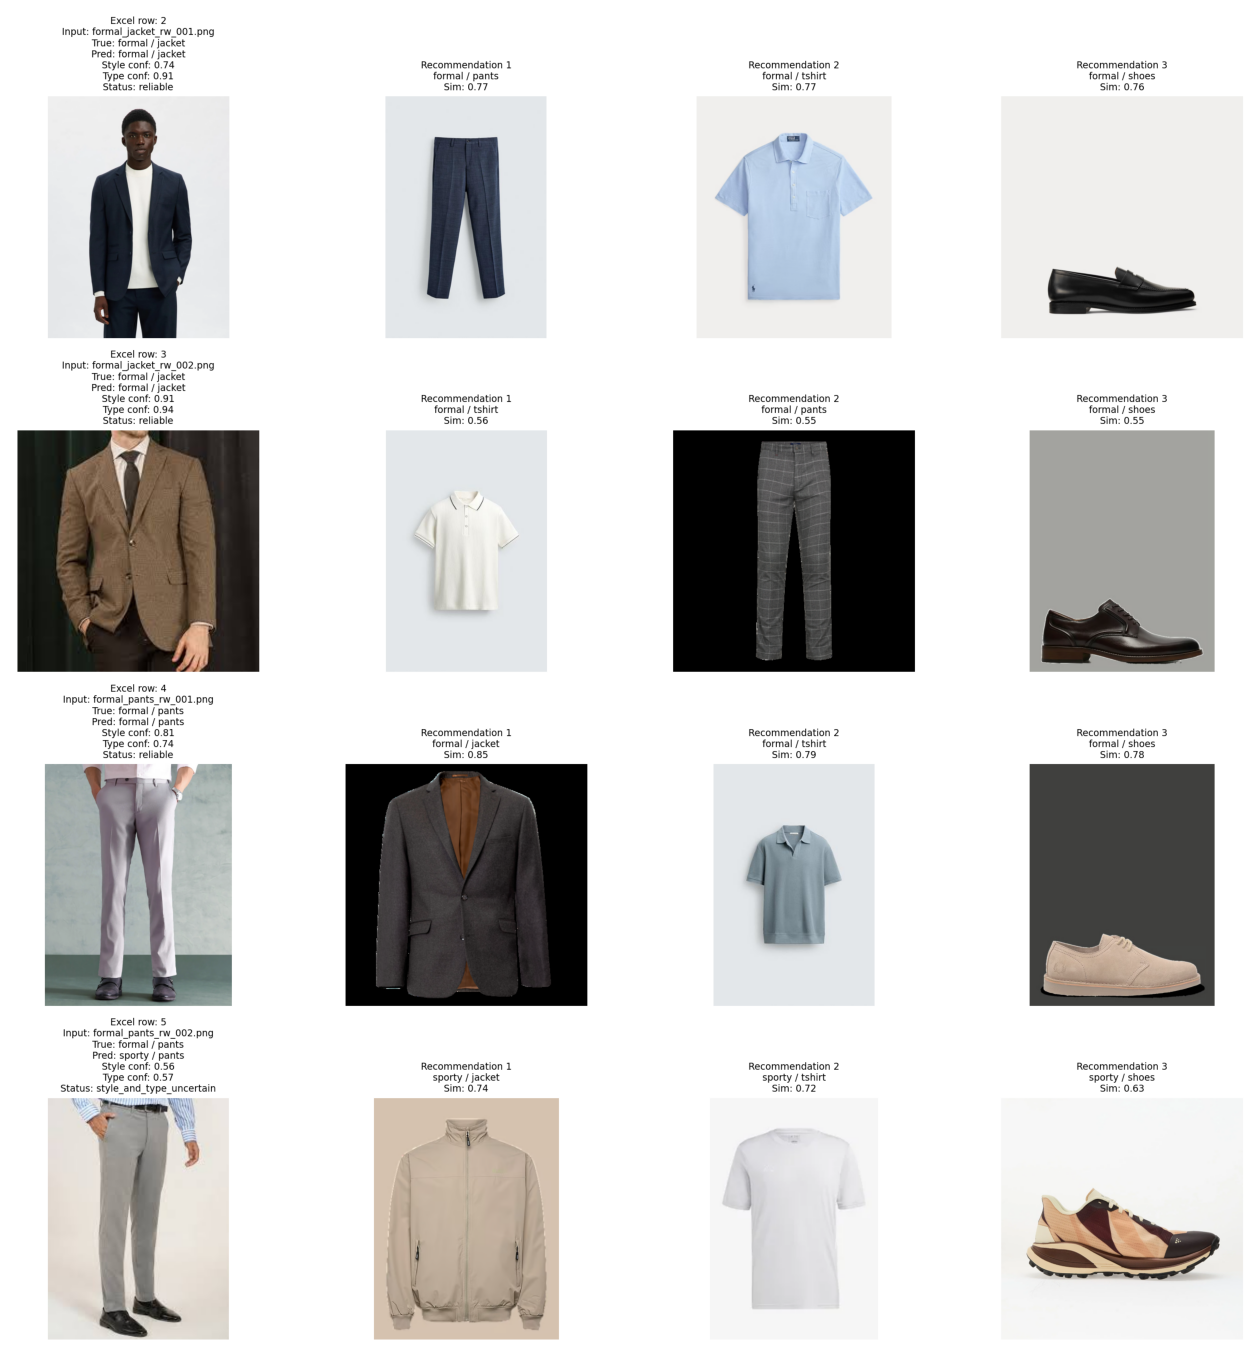

In [43]:
first_sheet_path = saved_sheet_paths[0]

img = Image.open(first_sheet_path)
plt.figure(figsize=(16, 18))
plt.imshow(img)
plt.axis("off")
plt.show()

## 20. Load Completed Manual Evaluation

Now that the manual scoring file is completed, I load it back into the notebook.

The completed Excel file contains the manual scores for all 32 recommendation examples.

After loading the scores, I merge them with the automatic evaluation results so that one final table contains both automatic metrics and manual scores.

In [44]:
manual_scores_path = manual_eval_dir / "clip_manual_scores_only_clean.xlsx"

manual_scores_df = pd.read_excel(manual_scores_path)

print("Rows:", len(manual_scores_df))
print("Columns:", manual_scores_df.columns.tolist())

manual_scores_df.head()

Rows: 32
Columns: ['input_image', 'filename', 'true_style', 'true_type', 'predicted_style', 'predicted_type', 'style_confidence', 'type_confidence', 'safeguard_status', 'style_correct', 'type_correct', 'recommended_styles', 'recommended_types', 'recommended_files', 'recommended_similarities', 'num_recommendations', 'same_actual_type_issue', 'structural_validity', 'style_consistency', 'visual_coherence', 'confidence_warning_usefulness', 'overall_quality', 'manual_notes']


,input_image,filename,true_style,true_type,predicted_style,predicted_type,style_confidence,type_confidence,safeguard_status,style_correct,...,recommended_files,recommended_similarities,num_recommendations,same_actual_type_issue,structural_validity,style_consistency,visual_coherence,confidence_warning_usefulness,overall_quality,manual_notes
0,..\dataset\real_world_test\formal\jacket\forma...,formal_jacket_rw_001.png,formal,jacket,formal,jacket,0.743481,0.907646,reliable,True,...,"['formal_pants_002.png', 'formal_tshirt_049.pn...","[0.772238552570343, 0.77081698179245, 0.758045...",3,False,2,2,2,2,2,Good recommendation. Correct formal jacket pre...
1,..\dataset\real_world_test\formal\jacket\forma...,formal_jacket_rw_002.png,formal,jacket,formal,jacket,0.908396,0.935415,reliable,True,...,"['formal_tshirt_009.png', 'formal_pants_036.pn...","[0.5641196966171265, 0.5549345016479492, 0.547...",3,False,2,2,2,2,2,Good recommendation. Correct formal jacket pre...
2,..\dataset\real_world_test\formal\pants\formal...,formal_pants_rw_001.png,formal,pants,formal,pants,0.808794,0.737623,reliable,True,...,"['formal_jacket_039.png', 'formal_tshirt_001.p...","[0.854070782661438, 0.7868897914886475, 0.7796...",3,False,2,2,2,2,2,Very good recommendation. Correct formal pants...
3,..\dataset\real_world_test\formal\pants\formal...,formal_pants_rw_002.png,formal,pants,sporty,pants,0.562956,0.573864,style_and_type_uncertain,False,...,"['sporty_jacket_023.png', 'sporty_tshirt_049.p...","[0.7370046377182007, 0.7207883596420288, 0.632...",3,False,2,0,1,2,1,Partially useful. The structure is correct bec...
4,..\dataset\real_world_test\formal\shoes\formal...,formal_shoes_rw_001.png,formal,shoes,formal,shoes,0.555320,0.978442,style_uncertain,True,...,"['formal_jacket_039.png', 'formal_pants_019.pn...","[0.7647998332977295, 0.7517022490501404, 0.729...",3,False,2,2,2,2,2,Good recommendation. Correct formal shoes pred...


In [45]:
required_score_columns = [
    "filename",
    "structural_validity",
    "style_consistency",
    "visual_coherence",
    "confidence_warning_usefulness",
    "overall_quality",
    "manual_notes"
]

manual_scores_df = manual_scores_df[required_score_columns].copy()

manual_scores_df.head()

,filename,structural_validity,style_consistency,visual_coherence,confidence_warning_usefulness,overall_quality,manual_notes
0,formal_jacket_rw_001.png,2,2,2,2,2,Good recommendation. Correct formal jacket pre...
1,formal_jacket_rw_002.png,2,2,2,2,2,Good recommendation. Correct formal jacket pre...
2,formal_pants_rw_001.png,2,2,2,2,2,Very good recommendation. Correct formal pants...
3,formal_pants_rw_002.png,2,0,1,2,1,Partially useful. The structure is correct bec...
4,formal_shoes_rw_001.png,2,2,2,2,2,Good recommendation. Correct formal shoes pred...


In [46]:
manual_completed_df = manual_eval_df.drop(
    columns=[
        "structural_validity",
        "style_consistency",
        "visual_coherence",
        "confidence_warning_usefulness",
        "overall_quality",
        "manual_notes"
    ],
    errors="ignore"
).merge(
    manual_scores_df,
    on="filename",
    how="left"
)

print("Rows:", len(manual_completed_df))
manual_completed_df.head()

Rows: 32


,input_image,filename,true_style,true_type,predicted_style,predicted_type,style_confidence,type_confidence,safeguard_status,style_correct,...,recommended_similarities,num_recommendations,same_actual_type_issue,recommendation_paths,structural_validity,style_consistency,visual_coherence,confidence_warning_usefulness,overall_quality,manual_notes
0,..\dataset\real_world_test\formal\jacket\forma...,formal_jacket_rw_001.png,formal,jacket,formal,jacket,0.743481,0.907646,reliable,True,...,"[0.772238552570343, 0.77081698179245, 0.758045...",3,False,[..\dataset\cleaned\formal\pants\formal_pants_...,2,2,2,2,2,Good recommendation. Correct formal jacket pre...
1,..\dataset\real_world_test\formal\jacket\forma...,formal_jacket_rw_002.png,formal,jacket,formal,jacket,0.908396,0.935415,reliable,True,...,"[0.5641196966171265, 0.5549345016479492, 0.547...",3,False,[..\dataset\cleaned\formal\tshirt\formal_tshir...,2,2,2,2,2,Good recommendation. Correct formal jacket pre...
2,..\dataset\real_world_test\formal\pants\formal...,formal_pants_rw_001.png,formal,pants,formal,pants,0.808794,0.737623,reliable,True,...,"[0.854070782661438, 0.7868897914886475, 0.7796...",3,False,[..\dataset\cleaned\formal\jacket\formal_jacke...,2,2,2,2,2,Very good recommendation. Correct formal pants...
3,..\dataset\real_world_test\formal\pants\formal...,formal_pants_rw_002.png,formal,pants,sporty,pants,0.562956,0.573864,style_and_type_uncertain,False,...,"[0.7370046377182007, 0.7207883596420288, 0.632...",3,False,[..\dataset\cleaned\sporty\jacket\sporty_jacke...,2,0,1,2,1,Partially useful. The structure is correct bec...
4,..\dataset\real_world_test\formal\shoes\formal...,formal_shoes_rw_001.png,formal,shoes,formal,shoes,0.555320,0.978442,style_uncertain,True,...,"[0.7647998332977295, 0.7517022490501404, 0.729...",3,False,[..\dataset\cleaned\formal\jacket\formal_jacke...,2,2,2,2,2,Good recommendation. Correct formal shoes pred...


In [47]:
manual_score_columns = [
    "structural_validity",
    "style_consistency",
    "visual_coherence",
    "confidence_warning_usefulness",
    "overall_quality"
]

manual_completed_df[manual_score_columns].isna().sum()

structural_validity              0
style_consistency                0
visual_coherence                 0
confidence_warning_usefulness    0
overall_quality                  0
dtype: int64

In [48]:
for column in manual_score_columns:
    values = sorted(manual_completed_df[column].dropna().unique())
    print(column, values)

structural_validity [np.int64(0), np.int64(2)]
style_consistency [np.int64(0), np.int64(1), np.int64(2)]
visual_coherence [np.int64(0), np.int64(1), np.int64(2)]
confidence_warning_usefulness [np.int64(0), np.int64(1), np.int64(2)]
overall_quality [np.int64(0), np.int64(1), np.int64(2)]


## 21. Manual Evaluation Summary

The manual evaluation summary calculates the average, median, minimum, and maximum score for each manual criterion.

The scores use the same 0 to 2 scale as before:

```text
0 = bad / not useful
1 = partially useful
2 = good / useful
```

The main metric for this experiment is visual coherence, because the goal is to test whether CLIP selects visually better recommendation items than ResNet34 embeddings.

In [49]:
manual_score_summary = manual_completed_df[manual_score_columns].agg(
    ["mean", "median", "min", "max"]
).transpose().reset_index()

manual_score_summary = manual_score_summary.rename(columns={
    "index": "criterion",
    "mean": "average_score",
    "median": "median_score",
    "min": "minimum_score",
    "max": "maximum_score"
})

manual_score_summary

,criterion,average_score,median_score,minimum_score,maximum_score
0,structural_validity,1.87500,2.0,0.0,2.0
1,style_consistency,1.53125,2.0,0.0,2.0
2,visual_coherence,1.62500,2.0,0.0,2.0
3,confidence_warning_usefulness,1.71875,2.0,0.0,2.0
4,overall_quality,1.56250,2.0,0.0,2.0


In [50]:
score_distribution_rows = []

for column in manual_score_columns:
    value_counts = manual_completed_df[column].value_counts().sort_index()

    score_distribution_rows.append({
        "criterion": column,
        "score_0_count": int(value_counts.get(0, 0)),
        "score_1_count": int(value_counts.get(1, 0)),
        "score_2_count": int(value_counts.get(2, 0))
    })

score_distribution_df = pd.DataFrame(score_distribution_rows)

score_distribution_df

,criterion,score_0_count,score_1_count,score_2_count
0,structural_validity,2,0,30
1,style_consistency,5,5,22
2,visual_coherence,1,10,21
3,confidence_warning_usefulness,4,1,27
4,overall_quality,1,12,19


In [51]:
overall_quality_counts = manual_completed_df["overall_quality"].value_counts().sort_index()

overall_quality_summary = pd.DataFrame({
    "overall_quality_score": [0, 1, 2],
    "meaning": ["bad", "partially useful", "good"],
    "count": [
        int(overall_quality_counts.get(0, 0)),
        int(overall_quality_counts.get(1, 0)),
        int(overall_quality_counts.get(2, 0))
    ]
})

overall_quality_summary["percentage"] = (
    overall_quality_summary["count"] / len(manual_completed_df)
)

overall_quality_summary

,overall_quality_score,meaning,count,percentage
0,0,bad,1,0.03125
1,1,partially useful,12,0.37500
2,2,good,19,0.59375


## 22. Comparison with ResNet34 Embedding Baseline

The CLIP embedding setup is compared with the current ResNet34 embedding baseline.

The classifiers stayed the same, so style accuracy and type accuracy did not change.

The important comparison is the manual recommendation quality, especially:

- visual coherence
- overall quality
- number of good recommendations
- number of bad recommendations

In [54]:
previous_manual_scores = {
    "structural_validity": 1.9375,
    "style_consistency": 1.46875,
    "visual_coherence": 1.3750,
    "confidence_warning_usefulness": 1.5625,
    "overall_quality": 1.40625
}

previous_manual_df = pd.DataFrame.from_dict(
    previous_manual_scores,
    orient="index",
    columns=["resnet34_embedding_baseline"]
)

clip_manual_df = manual_score_summary.set_index("criterion")[["average_score"]]
clip_manual_df = clip_manual_df.rename(columns={
    "average_score": "clip_embedding_setup"
})

manual_comparison_df = previous_manual_df.join(clip_manual_df)

manual_comparison_df["difference"] = (
    manual_comparison_df["clip_embedding_setup"] -
    manual_comparison_df["resnet34_embedding_baseline"]
)

manual_comparison_df

,resnet34_embedding_baseline,clip_embedding_setup,difference
structural_validity,1.93750,1.87500,-0.06250
style_consistency,1.46875,1.53125,0.06250
visual_coherence,1.37500,1.62500,0.25000
confidence_warning_usefulness,1.56250,1.71875,0.15625
overall_quality,1.40625,1.56250,0.15625


In [55]:
previous_quality_distribution = {
    "bad": 6,
    "partially_useful": 7,
    "good": 19
}

clip_quality_distribution = {
    "bad": int(overall_quality_summary.loc[
        overall_quality_summary["meaning"] == "bad",
        "count"
    ].values[0]),
    "partially_useful": int(overall_quality_summary.loc[
        overall_quality_summary["meaning"] == "partially useful",
        "count"
    ].values[0]),
    "good": int(overall_quality_summary.loc[
        overall_quality_summary["meaning"] == "good",
        "count"
    ].values[0])
}

quality_distribution_comparison_df = pd.DataFrame([
    {
        "quality_label": "bad",
        "resnet34_embedding_baseline": previous_quality_distribution["bad"],
        "clip_embedding_setup": clip_quality_distribution["bad"],
        "difference": clip_quality_distribution["bad"] - previous_quality_distribution["bad"]
    },
    {
        "quality_label": "partially_useful",
        "resnet34_embedding_baseline": previous_quality_distribution["partially_useful"],
        "clip_embedding_setup": clip_quality_distribution["partially_useful"],
        "difference": clip_quality_distribution["partially_useful"] - previous_quality_distribution["partially_useful"]
    },
    {
        "quality_label": "good",
        "resnet34_embedding_baseline": previous_quality_distribution["good"],
        "clip_embedding_setup": clip_quality_distribution["good"],
        "difference": clip_quality_distribution["good"] - previous_quality_distribution["good"]
    }
])

quality_distribution_comparison_df

,quality_label,resnet34_embedding_baseline,clip_embedding_setup,difference
0,bad,6,1,-5
1,partially_useful,7,12,5
2,good,19,19,0


### 22.1 Manual Comparison Interpretation

The manual comparison shows that replacing ResNet34 embeddings with CLIP embeddings improved the recommendation ranking quality.

The most important improvement is in visual coherence. The ResNet34 embedding baseline achieved a visual coherence score of **1.3750** out of 2, while the CLIP setup achieved **1.6250** out of 2. This is an improvement of **0.2500**.

This directly answers the main research question of the experiment. CLIP embeddings selected recommendation items that looked more visually coherent with the input item.

The overall quality score also improved from **1.40625** to **1.5625**, which is an improvement of **0.15625**. This means the recommendations became more useful overall.

Style consistency improved slightly from **1.46875** to **1.53125**. This suggests that CLIP ranking helped select items that matched the visual style better, even though the style classifier itself did not change.

Confidence warning usefulness also improved from **1.5625** to **1.71875**. This happened because several weak cases were correctly marked as uncertain, making the output easier to interpret.

Structural validity decreased slightly from **1.9375** to **1.8750**. This is not a major issue, but it happened because two examples still had structural problems caused by wrong type prediction. Since the type classifier was not changed, this is not mainly a CLIP ranking problem.

The overall quality distribution changed as follows:

```text
ResNet34 embedding baseline:
Good: 19
Partially useful: 7
Bad: 6

CLIP embedding setup:
Good: 19
Partially useful: 12
Bad: 1
```

The number of good recommendations stayed the same, but the number of bad recommendations dropped from 6 to 1. This is important because CLIP did not necessarily create more perfect recommendations, but it made the weak cases less bad.

Overall, CLIP embeddings improved the ranking stage of the recommendation pipeline. The improvement is especially clear in visual coherence and overall quality.

In [56]:
manual_completed_df.to_csv(
    results_dir / "clip_manual_evaluation_completed_clean.csv",
    index=False
)

manual_score_summary.to_csv(
    results_dir / "clip_manual_score_summary.csv",
    index=False
)

score_distribution_df.to_csv(
    results_dir / "clip_manual_score_distribution.csv",
    index=False
)

overall_quality_summary.to_csv(
    results_dir / "clip_overall_quality_summary.csv",
    index=False
)

manual_comparison_df.to_csv(
    results_dir / "manual_comparison_with_resnet34_embedding_baseline.csv"
)

quality_distribution_comparison_df.to_csv(
    results_dir / "quality_distribution_comparison_with_resnet34_embedding_baseline.csv",
    index=False
)

print("Manual evaluation outputs saved.")
print("Results folder:", results_dir)

Manual evaluation outputs saved.
Results folder: ..\results\recommendation_clip_embedding_ranking


In [57]:
experiment_summary = {
    "experiment": "CLIP Embedding Recommendation Ranking",
    "style_model": "style_mobilenet_v3_large_architecture_comparison.pth",
    "type_model": "type_resnet34_extra_data.pth",
    "catalogue": "dataset/cleaned",
    "evaluation_set": "32 balanced real-world examples",
    "baseline_embedding_extractor": "ResNet34",
    "new_embedding_extractor": "CLIP image encoder",
    "ranking_method": "cosine similarity",
    "style_confidence_threshold": style_confidence_threshold,
    "type_confidence_threshold": type_confidence_threshold,

    "style_accuracy": automatic_summary_df.loc[0, "style_accuracy"],
    "type_accuracy": automatic_summary_df.loc[0, "type_accuracy"],
    "same_actual_type_issues": int(
        automatic_summary_df.loc[0, "same_actual_type_issues"]
    ),

    "baseline_visual_coherence": 1.3750,
    "clip_visual_coherence": float(
        manual_score_summary.loc[
            manual_score_summary["criterion"] == "visual_coherence",
            "average_score"
        ].values[0]
    ),
    "visual_coherence_improvement": float(
        manual_score_summary.loc[
            manual_score_summary["criterion"] == "visual_coherence",
            "average_score"
        ].values[0] - 1.3750
    ),

    "baseline_overall_quality": 1.40625,
    "clip_overall_quality": float(
        manual_score_summary.loc[
            manual_score_summary["criterion"] == "overall_quality",
            "average_score"
        ].values[0]
    ),
    "overall_quality_improvement": float(
        manual_score_summary.loc[
            manual_score_summary["criterion"] == "overall_quality",
            "average_score"
        ].values[0] - 1.40625
    ),

    "clip_good_recommendations": int(
        overall_quality_summary.loc[
            overall_quality_summary["meaning"] == "good",
            "count"
        ].values[0]
    ),
    "clip_partially_useful_recommendations": int(
        overall_quality_summary.loc[
            overall_quality_summary["meaning"] == "partially useful",
            "count"
        ].values[0]
    ),
    "clip_bad_recommendations": int(
        overall_quality_summary.loc[
            overall_quality_summary["meaning"] == "bad",
            "count"
        ].values[0]
    ),

    "main_result": (
        "CLIP embeddings improved visual coherence and overall recommendation "
        "quality compared with the ResNet34 embedding baseline."
    ),
    "decision": (
        "CLIP image embeddings should replace ResNet34 embeddings for the "
        "recommendation ranking stage in the current prototype."
    ),
    "main_limitation": (
        "CLIP improves ranking, but the pipeline still depends on correct style "
        "and type predictions. Wrong classifier outputs can still lead to weak "
        "recommendations."
    ),
    "next_step": (
        "Use CLIP embeddings in the prototype and consider adding colour, occasion, "
        "or fashion-specific compatibility features later."
    )
}

experiment_summary_df = pd.DataFrame([experiment_summary])

experiment_summary_df

,experiment,style_model,type_model,catalogue,evaluation_set,baseline_embedding_extractor,new_embedding_extractor,ranking_method,style_confidence_threshold,type_confidence_threshold,...,baseline_overall_quality,clip_overall_quality,overall_quality_improvement,clip_good_recommendations,clip_partially_useful_recommendations,clip_bad_recommendations,main_result,decision,main_limitation,next_step
0,CLIP Embedding Recommendation Ranking,style_mobilenet_v3_large_architecture_comparis...,type_resnet34_extra_data.pth,dataset/cleaned,32 balanced real-world examples,ResNet34,CLIP image encoder,cosine similarity,0.6,0.6,...,1.40625,1.5625,0.15625,19,12,1,CLIP embeddings improved visual coherence and ...,CLIP image embeddings should replace ResNet34 ...,"CLIP improves ranking, but the pipeline still ...",Use CLIP embeddings in the prototype and consi...


In [58]:
experiment_summary_df.to_csv(
    results_dir / "clip_recommendation_experiment_summary.csv",
    index=False
)

print("Final experiment summary saved successfully.")
print("Results folder:", results_dir)

Final experiment summary saved successfully.
Results folder: ..\results\recommendation_clip_embedding_ranking


## 23. Conclusion

This experiment tested whether replacing ResNet34 image embeddings with CLIP image embeddings improves the recommendation ranking stage of the Outfit Recommendation System.

The classifiers were kept unchanged:

- MobileNetV3 Large for style classification
- improved ResNet34 for clothing type classification

The catalogue, confidence thresholds, ranking method, and 32-example real-world evaluation subset were also kept the same. Only the embedding extractor changed.

The automatic evaluation stayed the same as expected:

| Metric | Result |
|---|---:|
| Style accuracy | 0.65625 |
| Type accuracy | 0.9375 |
| Same-actual-type issues | 2 / 32 |
| Average recommendations | 3.0 |

This is expected because CLIP only changed the ranking stage, not the classifiers.

The manual evaluation showed that CLIP improved the recommendation quality:

| Criterion | ResNet34 embedding baseline | CLIP embedding setup | Difference |
|---|---:|---:|---:|
| Structural validity | 1.9375 | 1.8750 | -0.0625 |
| Style consistency | 1.46875 | 1.53125 | +0.0625 |
| Visual coherence | 1.3750 | 1.6250 | +0.2500 |
| Confidence warning usefulness | 1.5625 | 1.71875 | +0.15625 |
| Overall quality | 1.40625 | 1.5625 | +0.15625 |

The main improvement was visual coherence, which increased from **1.3750** to **1.6250**. This means CLIP selected recommendation items that visually matched the input better than the previous ResNet34 embedding method.

Overall quality also improved from **1.40625** to **1.5625**.

The quality distribution also improved:

| Quality | ResNet34 baseline | CLIP setup |
|---|---:|---:|
| Bad | 6 | 1 |
| Partially useful | 7 | 12 |
| Good | 19 | 19 |

The number of good recommendations stayed the same, but the number of bad recommendations decreased strongly. This means CLIP mainly improved the weaker cases and made the system more stable.

Based on these results, CLIP image embeddings are better than ResNet34 embeddings for the recommendation ranking stage. CLIP should replace ResNet34 embeddings in the current prototype.

However, the system still depends on the style and type classifiers. If the predicted style or type is wrong, the recommender can still retrieve weak or structurally incorrect recommendations. Future work should focus on improving classifier reliability, adding more fashion-specific attributes, and testing compatibility features beyond visual similarity.